In [1]:
# Cell 1 — Setup
import os, sys, copy
from pathlib import Path
os.chdir(Path(r"C:\Users\amand\OneDrive - Fisk University\Documents\ResumeBiasResearch"))
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.models.train import get_models, evaluate_classifier
from src.fairness.metrics import compute_all_fairness_metrics as compute_all
from src.fairness.intervention import compute_reweighting_weights
from src.fairness.group_definition import (
    get_gender_groups, get_ethnicity_groups, print_group_diagnostics,
)

sns.set_style("whitegrid")
data = np.load('data/processed/prepared_data.npz')
X_train, X_test = data['X_train'], data['X_test']

raw = np.load('data/raw/FairCVdb.npy', allow_pickle=True).item()
profiles_train = raw['Profiles Train']
profiles_test  = raw['Profiles Test']

gender_train    = get_gender_groups(profiles_train)
gender_test     = get_gender_groups(profiles_test)
ethnicity_train = get_ethnicity_groups(profiles_train)
ethnicity_test  = get_ethnicity_groups(profiles_test)

print("Gender (train):", pd.Series(gender_train).value_counts().to_dict())
print("Ethnicity (train):", pd.Series(ethnicity_train).value_counts().to_dict())

Gender (train): {1: 9637, 0: 9563}
Ethnicity (train): {1: 6412, 0: 6405, 2: 6383}


In [2]:
y_train = data['y_train_gender']   # start with gender-biased labels
y_test  = data['y_test_gender']

baseline_results = []
for name, model_proto in get_models().items():
    m = copy.deepcopy(model_proto)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    perf = evaluate_classifier(m, X_test, y_test)
    perf['model'] = name

    for attr_name, sensitive_test in [
        ('gender', gender_test),
        ('ethnicity', ethnicity_test),
    ]:
        print_group_diagnostics(y_test, y_pred, sensitive_test,
                                f"{name} / {attr_name}")
        fair = compute_all(y_test, y_pred, sensitive_test)
        baseline_results.append({
            'model': name,
            'attribute': attr_name,
            'stage': 'baseline',
            'accuracy': perf['accuracy'],
            'f1': perf['f1'],
            'auc': perf['auc'],
            'dpd': fair['demographic_parity_difference'],
            'eod': fair['equal_opportunity_difference'],
            'dir_min': min(fair['disparate_impact_ratios'].values()),
        })

baseline_df = pd.DataFrame(baseline_results)
print(baseline_df.to_string(index=False))


--- logistic_regression / gender group diagnostics ---
          n  selection_rate  base_rate  pct_of_total
group                                               
0      2437        0.627411   0.618794         50.77
1      2363        0.321202   0.335167         49.23
Using '0' as reference (highest selection rate)

--- logistic_regression / ethnicity group diagnostics ---
          n  selection_rate  base_rate  pct_of_total
group                                               
0      1595        0.475862   0.471473         33.23
1      1588        0.467884   0.475441         33.08
2      1617        0.486085   0.490414         33.69
Using '2' as reference (highest selection rate)

--- random_forest / gender group diagnostics ---
          n  selection_rate  base_rate  pct_of_total
group                                               
0      2437        0.633566   0.618794         50.77
1      2363        0.341092   0.335167         49.23
Using '0' as reference (highest selection rate)

-

In [5]:
intervened_results = []
for name, model_proto in get_models().items():
    # Reweight on the gender attribute (swap for ethnicity if desired)
    weights = compute_reweighting_weights(y_train, gender_train)
    m = copy.deepcopy(model_proto)
    m.fit(X_train, y_train, sample_weight=weights)
    y_pred = m.predict(X_test)
    perf = evaluate_classifier(m, X_test, y_test)

    for attr_name, sensitive_test in [
        ('gender', gender_test),
        ('ethnicity', ethnicity_test),
    ]:
        fair = compute_all(y_test, y_pred, sensitive_test)
        intervened_results.append({
            'model': name,
            'attribute': attr_name,
            'stage': 'reweighted',
            'accuracy': perf['accuracy'],
            'f1': perf['f1'],
            'auc': perf['auc'],
            'dpd': fair['demographic_parity_difference'],
            'eod': fair['equal_opportunity_difference'],
            'dir_min': min(fair['disparate_impact_ratios'].values()),
        })

intervened_df = pd.DataFrame(intervened_results)
print(intervened_df.to_string(index=False))

Using '0' as reference (highest selection rate)
Using '2' as reference (highest selection rate)
Using '0' as reference (highest selection rate)
Using '2' as reference (highest selection rate)
Using '0' as reference (highest selection rate)
Using '2' as reference (highest selection rate)
              model attribute      stage  accuracy       f1      auc      dpd      eod  dir_min
logistic_regression    gender reweighted  0.957292 0.955522 0.994307 0.298155 0.065965 0.525095
logistic_regression ethnicity reweighted  0.957292 0.955522 0.994307 0.019370 0.014422 0.960552
      random_forest    gender reweighted  0.861667 0.858904 0.942816 0.288780 0.096147 0.551175
      random_forest ethnicity reweighted  0.861667 0.858904 0.942816 0.005279 0.039313 0.989526
            xgboost    gender reweighted  0.937292 0.934208 0.987523 0.305876 0.096040 0.510237
            xgboost ethnicity reweighted  0.937292 0.934208 0.987523 0.013872 0.015615 0.971205


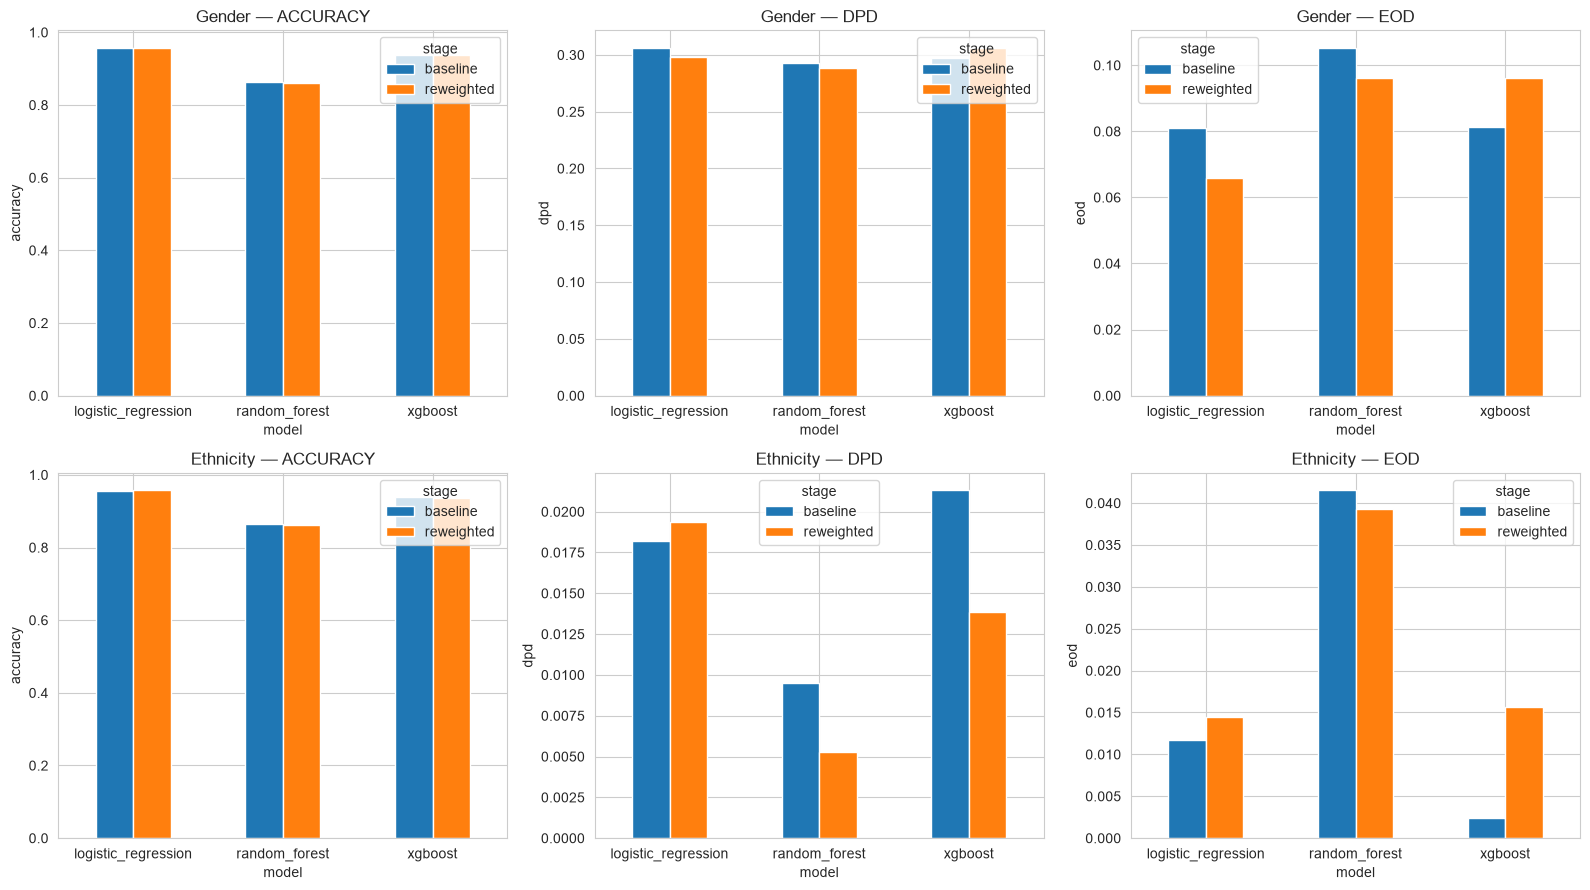

In [6]:
all_df = pd.concat([baseline_df, intervened_df], ignore_index=True)
all_df.to_csv('results/tables/fairness_intervention_comparison.csv', index=False)

# Before/after visualization, split by attribute
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for row, attr in enumerate(['gender', 'ethnicity']):
    sub = all_df[all_df['attribute'] == attr]
    for col, metric in enumerate(['accuracy', 'dpd', 'eod']):
        ax = axes[row, col]
        sub.pivot(index='model', columns='stage', values=metric).plot(
            kind='bar', ax=ax)
        ax.set_title(f'{attr.title()} — {metric.upper()}')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('results/figures/05_intervention_before_after.png',
            dpi=100, bbox_inches='tight')
plt.show()